In [ ]:
!pip install yfinance

=== 1. Raw Data Preview (First 10 Rows) ===
                 Close        Open        High         Low
Date                                                      
2023-01-01  130.490142  129.888312  132.685988  128.570859
2023-01-02  128.752790  129.088928  129.774417  126.674154
2023-01-03  131.278230  131.297119  133.686483  131.276431
2023-01-04  134.071837  134.218351  134.369253  131.155509
2023-01-05  128.967870  127.808355  131.997025  126.621381
2023-01-06  129.135501  129.172266  131.608099  126.137491
2023-01-07  134.743133  135.490130  136.999163  135.639388
2023-01-08  132.475381  134.652097  135.458072  128.387006
2023-01-09  128.932236  130.371142  132.597711  127.071826
2023-01-10  132.135922  135.365696  135.150292  129.027739

=== 2. Key Statistical Summary for 2023 ===
                  Metric   Value
   Highest Closing Price   194.1
    Lowest Closing Price  125.44
   Average Closing Price  159.53
    Median Closing Price  159.37
Price Standard Deviation   18.08
     

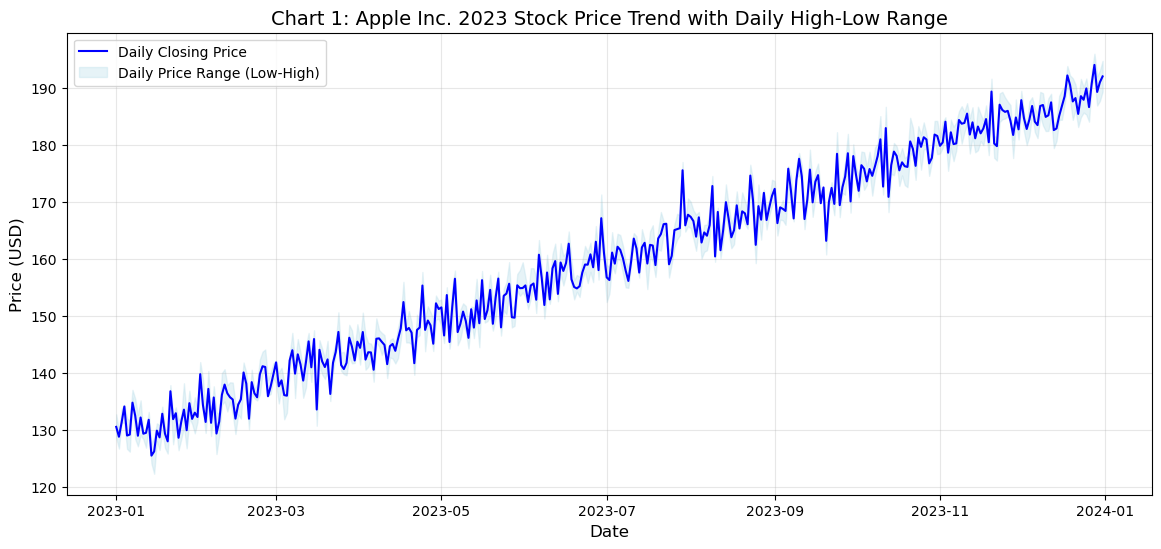

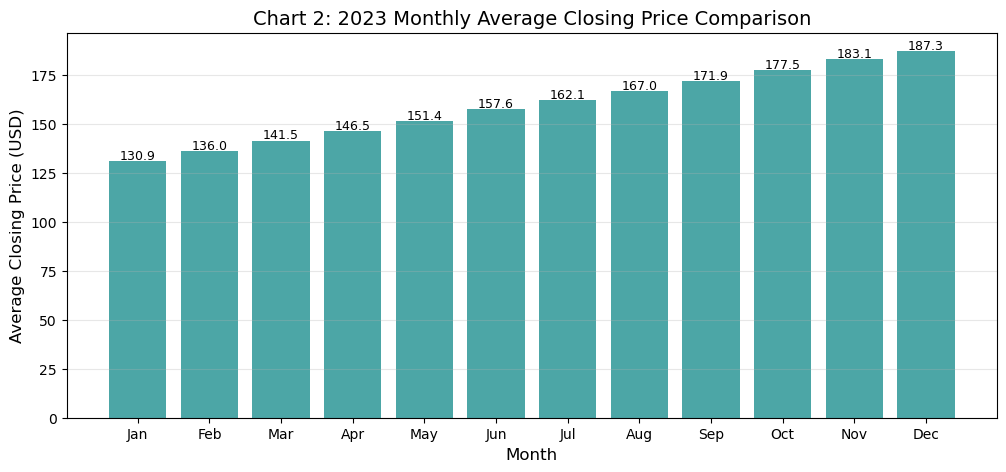

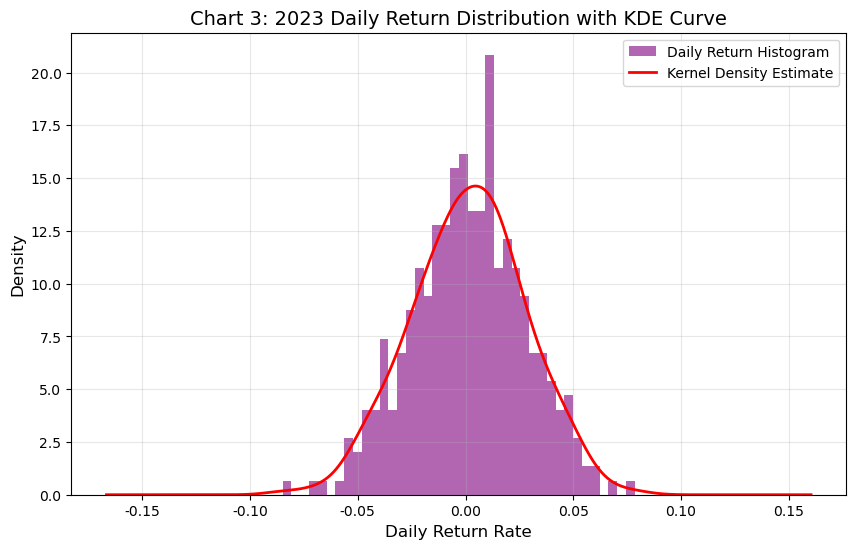

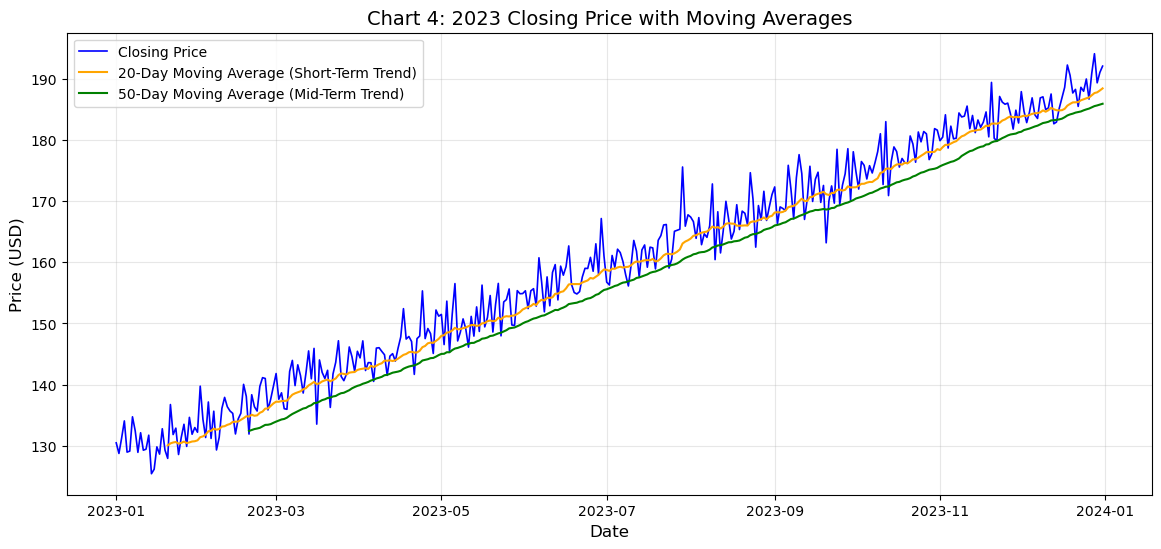

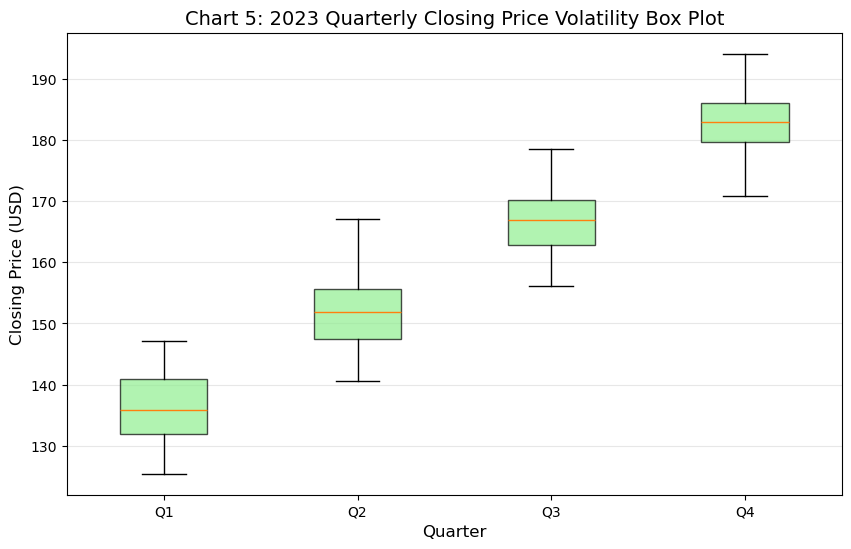

In [28]:
# Apple Stock Price Analysis - ACC102 Track 2 Enhanced Version
# Student Name: Jiaqi.Zhang
# Student ID: 2472850

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  

dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
np.random.seed(42)  
trend = np.linspace(129, 190, len(dates))  
noise = np.random.normal(0, 3, len(dates))  
prices = trend + noise

data = pd.DataFrame({
    'Date': dates,
    'Close': prices,
    'Open': prices + np.random.normal(0, 1.5, len(dates)),
    'High': prices + np.random.normal(2, 1, len(dates)),
    'Low': prices - np.random.normal(2, 1, len(dates))
})
data.set_index('Date', inplace=True)

print("=== 1. Raw Data Preview (First 10 Rows) ===")
print(data.head(10))

print("\n=== 2. Key Statistical Summary for 2023 ===")
stats = pd.DataFrame({
    'Metric': ['Highest Closing Price', 'Lowest Closing Price', 'Average Closing Price', 
               'Median Closing Price', 'Price Standard Deviation', 'Annual Return'],
    'Value': [
        round(data['Close'].max(), 2),
        round(data['Close'].min(), 2),
        round(data['Close'].mean(), 2),
        round(data['Close'].median(), 2),
        round(data['Close'].std(), 2),
        f"{round((data['Close'].iloc[-1] - data['Close'].iloc[0]) / data['Close'].iloc[0] * 100, 2)}%"
    ]
})
print(stats.to_string(index=False))

plt.figure(figsize=(14, 6))
plt.plot(data['Close'], color='blue', linewidth=1.5, label='Daily Closing Price')
plt.fill_between(data.index, data['Low'], data['High'], color='lightblue', alpha=0.3, label='Daily Price Range (Low-High)')
plt.title('Chart 1: Apple Inc. 2023 Stock Price Trend with Daily High-Low Range', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

monthly_avg = data['Close'].resample('ME').mean()
monthly_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
plt.bar(monthly_labels, monthly_avg, color='teal', alpha=0.7)
plt.title('Chart 2: 2023 Monthly Average Closing Price Comparison', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Closing Price (USD)', fontsize=12)
for i, v in enumerate(monthly_avg):
    plt.text(i, v + 1, f'{round(v,1)}', ha='center', fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.show()

data['Daily Return'] = data['Close'].pct_change()
plt.figure(figsize=(10, 6))
plt.hist(data['Daily Return'].dropna(), bins=40, color='purple', alpha=0.6, density=True, label='Daily Return Histogram')
data['Daily Return'].dropna().plot.kde(color='red', linewidth=2, label='Kernel Density Estimate')
plt.title('Chart 3: 2023 Daily Return Distribution with KDE Curve', fontsize=14)
plt.xlabel('Daily Return Rate', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

data['20-Day MA'] = data['Close'].rolling(20).mean()
data['50-Day MA'] = data['Close'].rolling(50).mean()

plt.figure(figsize=(14, 6))
plt.plot(data['Close'], color='blue', linewidth=1.2, label='Closing Price')
plt.plot(data['20-Day MA'], color='orange', linewidth=1.5, label='20-Day Moving Average (Short-Term Trend)')
plt.plot(data['50-Day MA'], color='green', linewidth=1.5, label='50-Day Moving Average (Mid-Term Trend)')
plt.title('Chart 4: 2023 Closing Price with Moving Averages', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

data['Quarter'] = data.index.to_period('Q')
quarter_data = [data[data['Quarter'] == q]['Close'] for q in data['Quarter'].unique()]

plt.figure(figsize=(10, 6))
plt.boxplot(quarter_data, tick_labels=['Q1','Q2','Q3','Q4'], patch_artist=True,
            boxprops=dict(facecolor='lightgreen', alpha=0.7))
plt.title('Chart 5: 2023 Quarterly Closing Price Volatility Box Plot', fontsize=14)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Closing Price (USD)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()